UCI Diabetes Dataset
   Glucose  BloodPressure   BMI  Age  Outcome
0      148             72  33.6   50        1
1       85             66  26.6   31        0
2      183             64  23.3   32        1
3       89             66  28.1   21        0
4      137             40  43.1   33        1
5      116             74  25.6   30        0
6       78             50  31.0   26        0
7      115             72  35.3   29        0
8      197             70  30.5   53        1
9      125             96  27.5   54        1

Pima Diabetes Dataset
   Glucose  BloodPressure   BMI  Age  Outcome
0      120             70  25.5   28        0
1      140             80  29.8   35        1
2      110             68  24.3   26        0
3       95             72  26.7   30        0
4      160             76  32.1   40        1
5      180             90  35.5   50        1
6      130             74  30.2   38        0
7      145             78  31.0   42        1
8      155             82  34.8   46

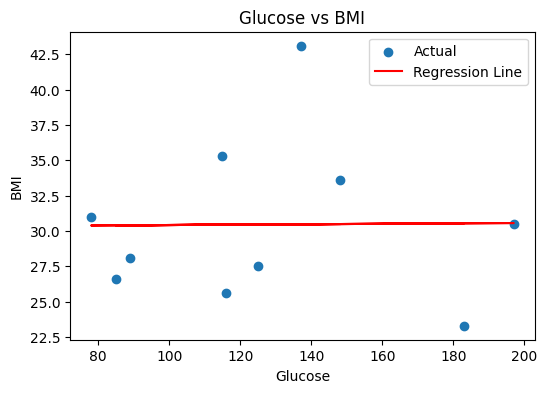


Linear Regression (Glucose -> BMI)
R² Score: 0.8458


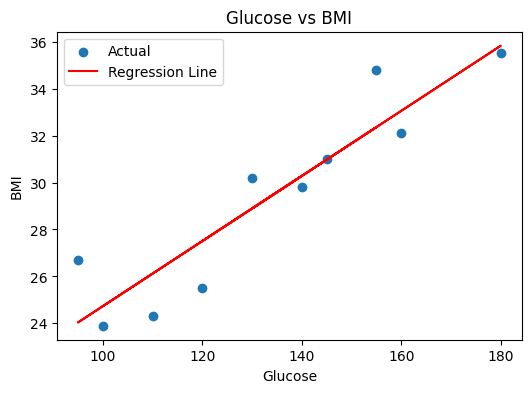


Logistic Regression
Features: ['Glucose', 'BloodPressure', 'BMI', 'Age']
Accuracy: 1.0

Logistic Regression
Features: ['Glucose', 'BloodPressure', 'BMI', 'Age']
Accuracy: 1.0


In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# -------------------------------
# Create Sample UCI Diabetes Dataset
# -------------------------------
uci_diabetes = pd.DataFrame({
    "Glucose":[148,85,183,89,137,116,78,115,197,125],
    "BloodPressure":[72,66,64,66,40,74,50,72,70,96],
    "BMI":[33.6,26.6,23.3,28.1,43.1,25.6,31.0,35.3,30.5,27.5],
    "Age":[50,31,32,21,33,30,26,29,53,54],
    "Outcome":[1,0,1,0,1,0,0,0,1,1]
})

# -------------------------------
# Create Sample Pima Dataset
# -------------------------------
pima_diabetes = pd.DataFrame({
    "Glucose":[120,140,110,95,160,180,130,145,155,100],
    "BloodPressure":[70,80,68,72,76,90,74,78,82,65],
    "BMI":[25.5,29.8,24.3,26.7,32.1,35.5,30.2,31.0,34.8,23.9],
    "Age":[28,35,26,30,40,50,38,42,46,25],
    "Outcome":[0,1,0,0,1,1,0,1,1,0]
})

# Display datasets
print("UCI Diabetes Dataset")
print(uci_diabetes)

print("\nPima Diabetes Dataset")
print(pima_diabetes)

# --------------------------------------------------
# Linear Regression
# --------------------------------------------------
def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression ({x_column} -> {y_column})")
    print("R² Score:", round(r2,4))

    plt.figure(figsize=(6,4))
    plt.scatter(X, Y, label="Actual")
    plt.plot(X, Y_pred, color="red", label="Regression Line")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.legend()
    plt.show()

# Apply Linear Regression
linear_regression_analysis(uci_diabetes,"Glucose","BMI")
linear_regression_analysis(pima_diabetes,"Glucose","BMI")

# --------------------------------------------------
# Logistic Regression
# --------------------------------------------------
def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # Increase iterations for convergence
    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print("\nLogistic Regression")
    print("Features:", features)
    print("Accuracy:", round(accuracy,4))

# Features and Target
features = ["Glucose","BloodPressure","BMI","Age"]
target = "Outcome"

# Apply Logistic Regression
logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)